# Regex+Str分析(EDA)
## 伯克利接警记录

In [2]:
# Initialize Otter
import otter
grader = otter.Notebook("lab03.ipynb")

In [3]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 9)

## 获取数据

In [4]:
# Run this cell to download the data, no further action is needed.
from ds100_utils import download_lab3_data

dest_path = download_lab3_data()
print(f'Located at {dest_path}')

Using cached version that was downloaded (UTC): Mon Aug 11 10:27:12 2025
Located at data\lab03_data_sp24.zip


In [5]:
# 解压文件
# Run this cell to unzip the data, no further action is needed.
my_zip = zipfile.ZipFile(dest_path, 'r')
my_zip.extractall('data')

In [6]:
# 查看文件
# Run this cell to view the content in the zip file, no further action is needed.
import os

for root, directories, filenames in os.walk('data'):
    # first, print out all directories
    for directory in directories:
        dpath = os.path.join(root, directory)
        print(f"d {dpath}")

    # next, print out all files
    for filename in filenames:
        fpath = os.path.join(root,filename)
        print(f"  {fpath}")

d data\secret
  data\Berkeley_PD_-_Calls_for_Service_2022.csv
  data\dummy.txt
  data\hello_world.py
  data\lab03_data_sp24.zip
  data\secret\do_not_readme.md


# 清洗并探索数据

In [7]:
# 读取到DataFrame并将时间列转换为时间戳
calls = pd.read_csv("data/Berkeley_PD_-_Calls_for_Service_2022.csv")
calls['EVENTTM'] = pd.to_datetime(calls['EVENTTM']).dt.strftime('%H:%M:%S %p')

C:\Users\e\AppData\Local\Temp\ipykernel_18908\3211410272.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calls['EVENTTM'] = pd.to_datetime(calls['EVENTTM']).dt.strftime('%H:%M:%S %p')


In [8]:
calls.head()

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State
0,22036516,THEFT FROM AUTO,08/10/2022 12:00:00 AM,06:10:00 AM,LARCENY - FROM VEHICLE,3,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA
1,22027674,BURGLARY RESIDENTIAL,06/16/2022 12:00:00 AM,20:25:00 PM,BURGLARY - RESIDENTIAL,4,10/13/2022 04:42:00 PM,"1700 BLOCK OXFORD ST\nBerkeley, CA\n(37.87674,...",1700 BLOCK OXFORD ST,Berkeley,CA
2,22023993,VANDALISM,05/25/2022 12:00:00 AM,08:00:00 AM,VANDALISM,3,10/13/2022 04:42:00 PM,"2400 BLOCK 8TH ST\nBerkeley, CA\n(37.86206, -1...",2400 BLOCK 8TH ST,Berkeley,CA
3,22026547,DISTURBANCE,06/10/2022 12:00:00 AM,21:35:00 PM,DISORDERLY CONDUCT,5,10/13/2022 04:42:00 PM,"1300 BLOCK HEARST AVE\nBerkeley, CA\n(37.87133...",1300 BLOCK HEARST AVE,Berkeley,CA
4,22018126,ASSAULT/BATTERY FEL.,04/20/2022 12:00:00 AM,15:31:00 PM,ASSAULT,3,10/13/2022 04:42:00 PM,"3000 BLOCK SHATTUCK AVE\nBerkeley, CA\n(37.855...",3000 BLOCK SHATTUCK AVE,Berkeley,CA


我们可以看到，这些字段包括案件编号、犯罪类型、犯罪发生的日期和时间、与犯罪类型相关的“CVLEGEND”、没有明显含义的“CVDOW”、记录被添加到数据库的日期，以及分布在四个字段中的地点信息。

In [9]:
calls.describe()

,CASENO,CVDOW
count,4.490000e+03,4490.000000
mean,2.204229e+07,3.075724
std,2.222561e+04,1.976035
min,2.200110e+07,0.000000
25%,2.202749e+07,1.000000
50%,2.203642e+07,3.000000
75%,2.204490e+07,5.000000
max,2.209134e+07,6.000000


通过分组`City`和`State`列来验证是否所有事件都发生在Berkeley

In [10]:
calls.groupby(["City", "State"]).size()
# Size == 4490 说明按"City"和"State"分组后，所有记录都是一组的

City      State
Berkeley  CA       4490
dtype: int64

In [11]:
calls['OFFENSE'].value_counts().head(10)

OFFENSE
THEFT MISD. (UNDER $950)    660
THEFT FELONY (OVER $950)    454
BURGLARY AUTO               446
DISTURBANCE                 437
VEHICLE STOLEN              332
THEFT FROM AUTO             294
VANDALISM                   264
ASSAULT/BATTERY MISD.       249
BURGLARY RESIDENTIAL        244
BURGLARY COMMERCIAL         174
Name: count, dtype: int64

In [12]:
calls['CVLEGEND'].value_counts().head(10)

CVLEGEND
LARCENY                   1127
BURGLARY - VEHICLE         446
DISORDERLY CONDUCT         437
ASSAULT                    344
MOTOR VEHICLE THEFT        332
LARCENY - FROM VEHICLE     294
VANDALISM                  264
BURGLARY - RESIDENTIAL     244
FRAUD                      209
BURGLARY - COMMERCIAL      174
Name: count, dtype: int64

### Q1  设置`answer1`为   当`CVLEGEND`为`LARCENY`时`OFFENSE`的可能值对应的字符串‘列表’
可能值：使用unique()去重

In [13]:
answer1 = calls[calls['CVLEGEND'] == 'LARCENY'].loc[:,'OFFENSE'].unique().tolist()
answer1

['THEFT MISD. (UNDER $950)', 'THEFT FELONY (OVER $950)', 'THEFT FROM PERSON']

In [14]:
grader.check("q1")

q1 results: All test cases passed!

Demo 2: Using axes methods to update plot


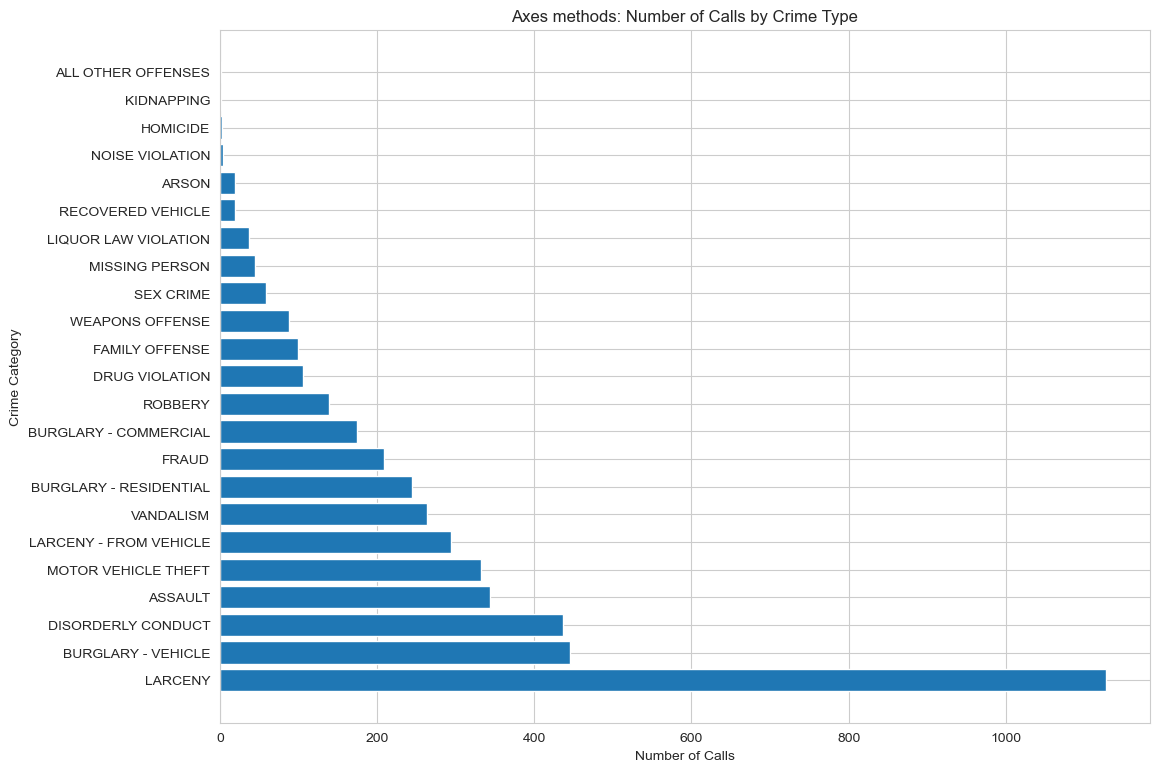

In [15]:
# DEMO CELL: assign demo to 1 or 2.
demo = 2

calls_cvlegend = calls['CVLEGEND'].value_counts()

if demo == 1:
    plt.barh(calls_cvlegend.index, calls_cvlegend) # Creates figure and axes
    print(f"Demo {demo}: Using plt methods to update plot")
    plt.ylabel("Crime Category")               # Uses most recently plotted axes
    plt.xlabel("Number of Calls")
    plt.title("Number of Calls by Crime Type")
elif demo == 2:
    print(f"Demo {demo}: Using axes methods to update plot")
    plt.barh(calls_cvlegend.index, calls_cvlegend) # Creates figure and axes
    ax = plt.gca()
    ax.set_ylabel("Crime Category")
    ax.set_xlabel("Number of Calls")
    ax.set_title("Axes methods: Number of Calls by Crime Type")
else:
    print("Error: Please assign the demo variable to 1 or 2.")

plt.show()

## Q2 使用matplotlib绘图
### Q2a 在calls中根据`CVDOW`新建`Day`列，0-Sunday, 1-Monday, ..., 6-Saturday；**使用`Series.map`**
`Series.map`方法传入一个dict或Series

In [16]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_indices = range(7)
indices_to_days_dict = dict(zip(day_indices, days)) # Should look like {0:"Sunday", 1:"Monday", ..., 6:"Saturday"}

calls["Day"] = calls['CVDOW'].map(indices_to_days_dict)

In [17]:
grader.check("q2a")

q2a results: All test cases passed!

### Q2b 从`EVENTTM`列中提取小时信息作为calls['Hour']的新int列

In [18]:
calls.head()

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State,Day
0,22036516,THEFT FROM AUTO,08/10/2022 12:00:00 AM,06:10:00 AM,LARCENY - FROM VEHICLE,3,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Wednesday
1,22027674,BURGLARY RESIDENTIAL,06/16/2022 12:00:00 AM,20:25:00 PM,BURGLARY - RESIDENTIAL,4,10/13/2022 04:42:00 PM,"1700 BLOCK OXFORD ST\nBerkeley, CA\n(37.87674,...",1700 BLOCK OXFORD ST,Berkeley,CA,Thursday
2,22023993,VANDALISM,05/25/2022 12:00:00 AM,08:00:00 AM,VANDALISM,3,10/13/2022 04:42:00 PM,"2400 BLOCK 8TH ST\nBerkeley, CA\n(37.86206, -1...",2400 BLOCK 8TH ST,Berkeley,CA,Wednesday
3,22026547,DISTURBANCE,06/10/2022 12:00:00 AM,21:35:00 PM,DISORDERLY CONDUCT,5,10/13/2022 04:42:00 PM,"1300 BLOCK HEARST AVE\nBerkeley, CA\n(37.87133...",1300 BLOCK HEARST AVE,Berkeley,CA,Friday
4,22018126,ASSAULT/BATTERY FEL.,04/20/2022 12:00:00 AM,15:31:00 PM,ASSAULT,3,10/13/2022 04:42:00 PM,"3000 BLOCK SHATTUCK AVE\nBerkeley, CA\n(37.855...",3000 BLOCK SHATTUCK AVE,Berkeley,CA,Wednesday


In [19]:
calls['Hour'] = calls['EVENTTM'].str[:2].astype(int)
calls['Hour']

0        6
1       20
2        8
3       21
4       15
        ..
4485    16
4486     1
4487     5
4488    20
4489    12
Name: Hour, Length: 4490, dtype: int32

In [20]:
grader.check("q2b")

q2b results: All test cases passed!

### Q2c 使用`matplotlib`的`plot`绘制折线图，横轴为小时，纵轴为每个小时的案件/记录数

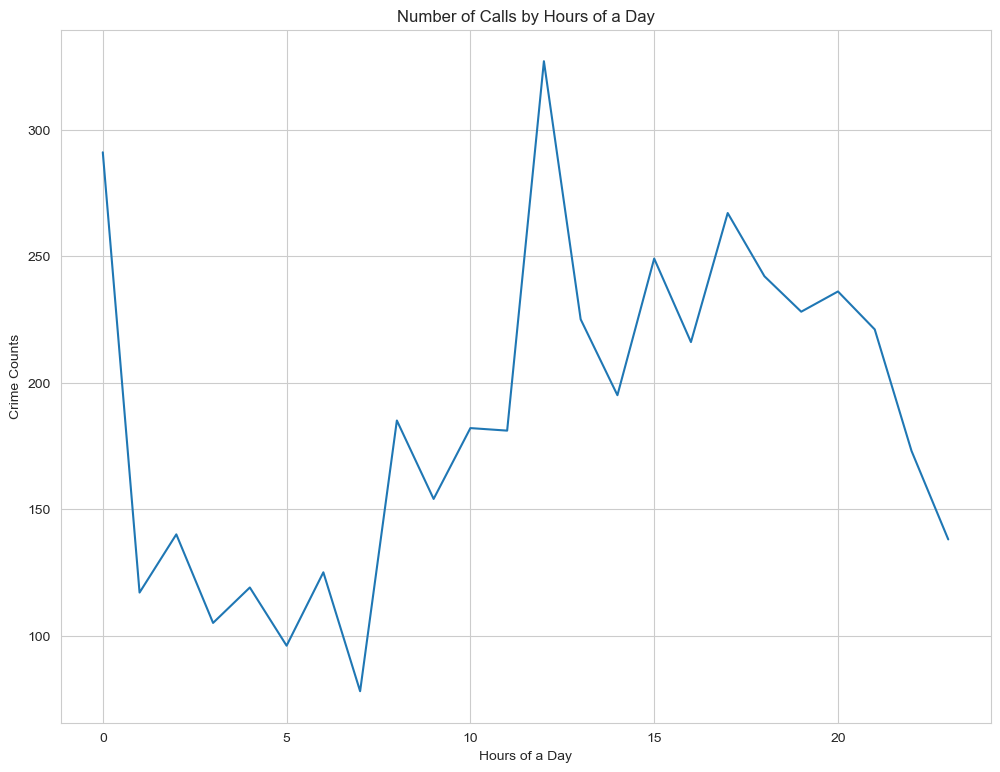

In [21]:
calls_by_hour = calls['Hour'].value_counts().sort_index()
plt.plot(calls_by_hour.index, calls_by_hour) # Creates figure and axes

plt.ylabel("Crime Counts")               # Uses most recently plotted axes
plt.xlabel("Hours of a Day")
plt.title("Number of Calls by Hours of a Day")
# plt.show()
ax_3d = plt.gca()

In [22]:
grader.check("q2c")

q2c results: All test cases passed!

Text(0.5, 1.0, 'Stratified Analysis of Phone Calls by Day')

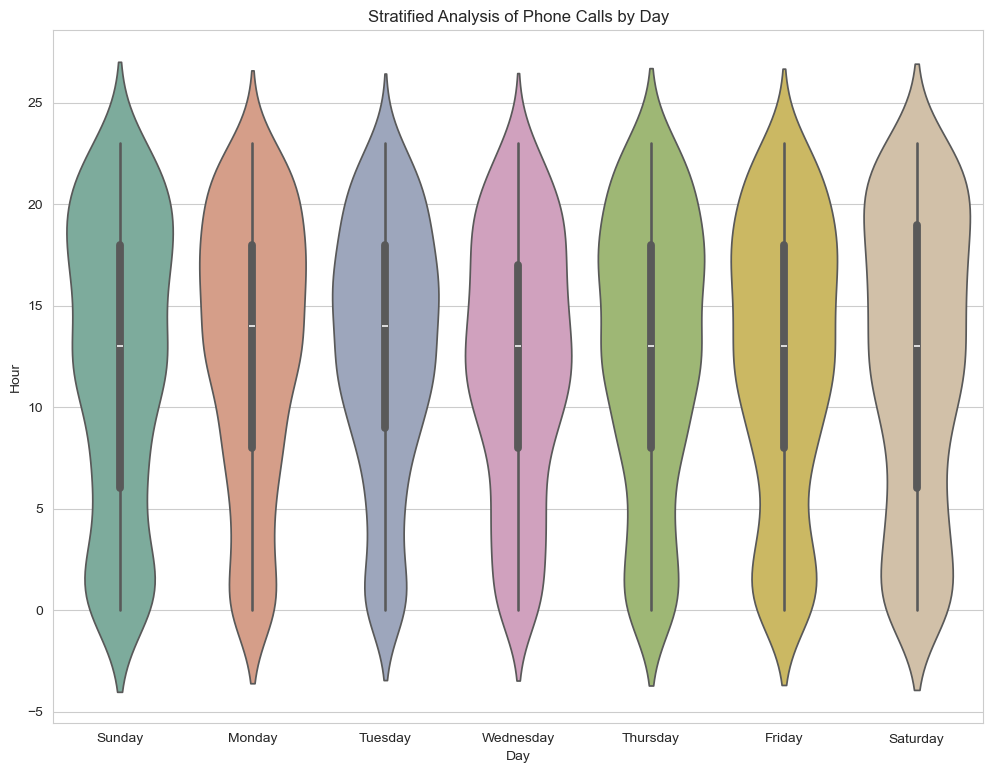

In [23]:
# Run this cell to to generate the plot, no further action is needed

import seaborn as sns
ax = sns.violinplot(
    data=calls.sort_values("CVDOW"),
    x="Day", y="Hour",
    hue="Day",  # 新增
    legend=False,  # 新增
    saturation=0.5, palette="Set2"
)
ax.set_title("Stratified Analysis of Phone Calls by Day")

### Q2d

## Q3 从每个记录的`Block_Location`中提取经纬度
### Q3a 使用正则表达式+`Series.str.extract`方法从`['Block_Location']`提取经纬度
()圆括号做捕获/capture；匹配圆括号要反义\(

In [24]:
calls.loc[:4, 'Block_Location']

0                 Berkeley, CA\n(37.86988, -122.27054)
1    1700 BLOCK OXFORD ST\nBerkeley, CA\n(37.87674,...
2    2400 BLOCK 8TH ST\nBerkeley, CA\n(37.86206, -1...
3    1300 BLOCK HEARST AVE\nBerkeley, CA\n(37.87133...
4    3000 BLOCK SHATTUCK AVE\nBerkeley, CA\n(37.855...
Name: Block_Location, dtype: object

In [25]:
# calls_lat = calls['Block_Location'].str.extract(r'\((.*)\,')
# calls_lon = calls['Block_Location'].str.extract(r'\,(.*)\)')
# calls_lat_lon = pd.DataFrame({'Lat': calls_lat[0], 'Lon': calls_lon[0]})

# 一个正则表达式可以同时提取lat和lon
calls_lat_lon = calls['Block_Location'].str.extract(r'\((.*)\, (.*)\)')
calls_lat_lon.columns = ['Lat', 'Lon']  # 重命名列
calls_lat_lon.head(10)

,Lat,Lon
0,37.86988,-122.27054
1,37.87674,-122.26665
2,37.86206,-122.29346
3,37.87133,-122.28656
4,37.85507,-122.26677
5,37.86397,-122.26036
6,37.87025,-122.29843
7,37.87637,-122.26229
8,37.86725,-122.26326
9,37.86746,-122.29285


In [26]:
grader.check("q3a")

q3a results: All test cases passed!

### Q3b 连接表
将`calls_lat_lon`连接到`calls`表中
注意二者中记录顺序相同

In [27]:
# calls.drop(['lat', 'lon', 'lat_x', 'lat_y', 'lon_x', 'lon_y', 'Lat','Lon'], axis=1, inplace=True, errors='ignore')  # 删除可能存在的旧列
# calls.head()

In [28]:
# calls["Lat"], calls['Lon'] = calls_lat_lon['Lat'], calls_lat_lon['Lon']
# calls.sample(5)

# 使用merge方法
calls = calls.merge(calls_lat_lon, left_index=True, right_index=True)
calls.sample(5)

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State,Day,Hour,Lat,Lon
408,22090695,THEFT FELONY (OVER $950),06/06/2022 12:00:00 AM,01:50:00 AM,LARCENY,1,10/13/2022 04:42:00 PM,"700 BLOCK CRAGMONT AVE\nBerkeley, CA\n(37.8981...",700 BLOCK CRAGMONT AVE,Berkeley,CA,Monday,1,37.89812,-122.26823
3841,22091106,THEFT MISD. (UNDER $950),09/05/2022 12:00:00 AM,11:30:00 AM,LARCENY,1,10/13/2022 04:42:00 PM,"2000 BLOCK ALLSTON WAY\nBerkeley, CA\n(37.8691...",2000 BLOCK ALLSTON WAY,Berkeley,CA,Monday,11,37.8691,-122.27008
3618,22028070,BURGLARY AUTO,06/18/2022 12:00:00 AM,18:30:00 PM,BURGLARY - VEHICLE,6,10/13/2022 04:42:00 PM,"TREMONT ST / PRINCE ST\nBerkeley, CA\n(37.8528...",TREMONT ST / PRINCE ST,Berkeley,CA,Saturday,18,37.8528,-122.26811
1164,22090690,THEFT MISD. (UNDER $950),06/06/2022 12:00:00 AM,08:00:00 AM,LARCENY,1,10/13/2022 04:42:00 PM,"1500 BLOCK DERBY ST\nBerkeley, CA\n(37.85836, ...",1500 BLOCK DERBY ST,Berkeley,CA,Monday,8,37.85836,-122.27892
1500,22032886,FRAUD/FORGERY,07/19/2022 12:00:00 AM,11:15:00 AM,FRAUD,2,10/13/2022 04:42:00 PM,"2300 BLOCK PARKER ST\nBerkeley, CA\n(37.86278,...",2300 BLOCK PARKER ST,Berkeley,CA,Tuesday,11,37.86278,-122.26238


In [29]:
grader.check("q3b")

q3b results: All test cases passed!

### Q3c 检查是否有无效的GPS坐标，即‘NaN’值

In [30]:
(~calls[["Lat", "Lon"]].isna()).mean()
# (...).mean()：对布尔值取均值，True会被当作1，False当作0，所以取均值就是非NaN值的比例

Lat    1.0
Lon    1.0
dtype: float64

根据`BLKADDR`判断地址是否有效，根据前文，这一列有空值<br>
根据`BLKADDR`创建新的'DataFrame'`invalid_block_loc`，其中仅包含具有无效'Block_Location'的记录

In [31]:
invalid_block_loc = calls[calls['BLKADDR'].isna()]
invalid_block_loc.head()

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State,Day,Hour,Lat,Lon
0,22036516,THEFT FROM AUTO,08/10/2022 12:00:00 AM,06:10:00 AM,LARCENY - FROM VEHICLE,3,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Wednesday,6,37.86988,-122.27054
574,22091101,THEFT FELONY (OVER $950),09/04/2022 12:00:00 AM,11:55:00 AM,LARCENY,0,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Sunday,11,37.86988,-122.27054
703,22091162,BURGLARY AUTO,08/29/2022 12:00:00 AM,10:15:00 AM,BURGLARY - VEHICLE,1,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Monday,10,37.86988,-122.27054
1135,22090479,BURGLARY AUTO,04/20/2022 12:00:00 AM,01:00:00 AM,BURGLARY - VEHICLE,3,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Wednesday,1,37.86988,-122.27054
1314,22045306,THEFT FELONY (OVER $950),09/27/2022 12:00:00 AM,02:10:00 AM,LARCENY,2,10/13/2022 04:42:00 PM,"Berkeley, CA\n(37.86988, -122.27054)",NaN,Berkeley,CA,Tuesday,2,37.86988,-122.27054


In [32]:
grader.check("q3c")

q3c results: All test cases passed!

### Q3d 探索哪种类型的数据更容易缺乏有效的'BLKADDR'

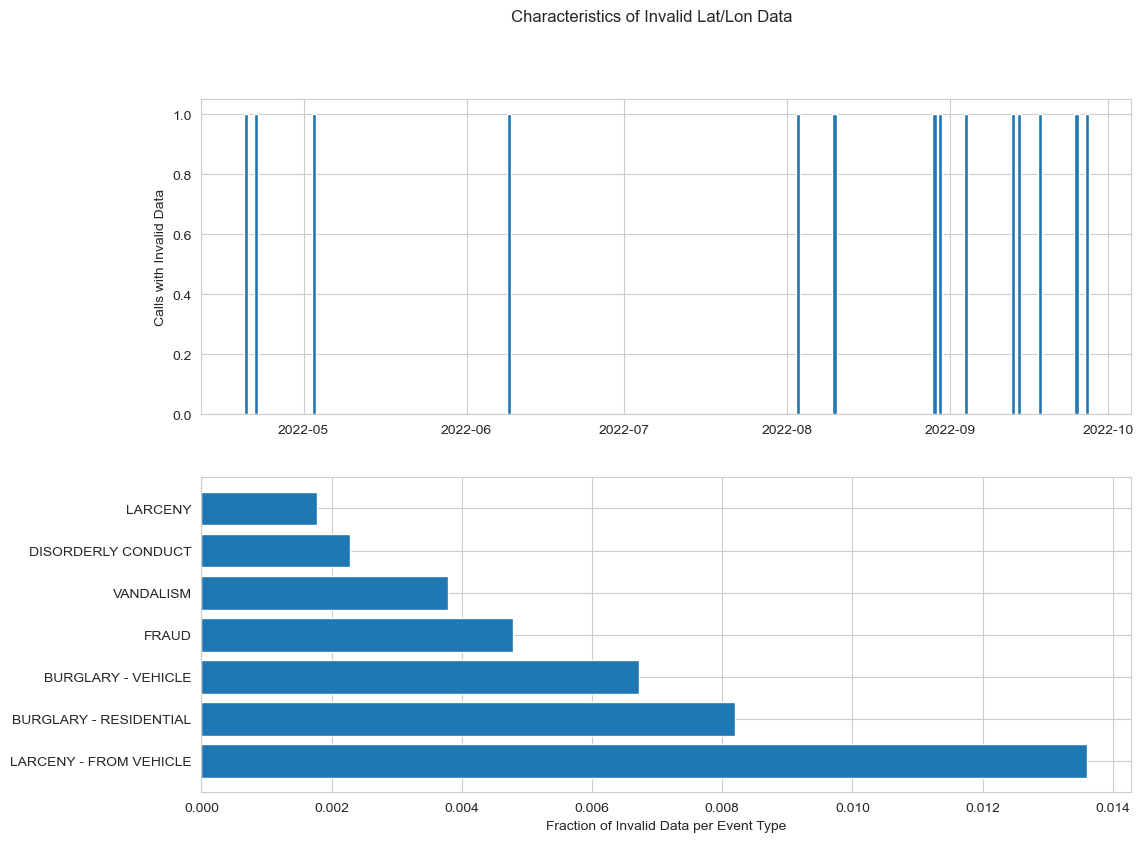

In [33]:
# Run this cell to generate the plot, no further action is needed
missing_by_time = (pd.to_datetime(invalid_block_loc['EVENTDT'], format='%m/%d/%Y %I:%M:%S %p')
                   .value_counts()
                   .sort_index()
                  )
missing_by_crime = (invalid_block_loc['CVLEGEND']
                    .value_counts()
                    / calls['CVLEGEND'].value_counts()
                   ).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(2)
ax[0].bar(missing_by_time.index, missing_by_time)
ax[0].set_ylabel("Calls with Invalid Data")
ax[1].barh(missing_by_crime.index, missing_by_crime)
ax[1].set_xlabel("Fraction of Invalid Data per Event Type")
fig.suptitle("Characteristics of Invalid Lat/Lon Data")
plt.show()

### Q3e 探索

In [34]:
# Run this cell to generate the interactive plot, no further code is needed.
import folium
import folium.plugins

BERKELEY_COORDINATES = (37.87, -122.28)
berkeley_map = folium.Map(location=BERKELEY_COORDINATES, zoom_start=13)
locs = calls.drop(invalid_block_loc.index)[['Lat', 'Lon']].astype('float').values
heatmap = folium.plugins.HeatMap(locs.tolist(), radius=10)
berkeley_map.add_child(heatmap)